In [1]:
import os
import numpy as np
from scipy.fftpack import fft2
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager
from pathlib import Path
from prf_expect.utils.beh import calculate_visual_angle
from prf_expect.utils import io
from prf_expect.utils.viz import cm_to_inch

In [2]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc('pdf', fonttype=42, use14corefonts=False)
rc('axes', linewidth=0.5)
rc('font',**{'family':'Arial'})
rc('text', usetex=False)
rc('xtick', labelsize=6)
rc('ytick', labelsize=6)
rc('axes', labelsize=6)
rc('legend', fontsize=6)

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1

In [3]:
figure_result_dir = Path(cwd).parent / "figures"
bar_image_path = Path("./pRFbar_Screenshots275.png")
bar_image = plt.imread(bar_image_path)

In [4]:
# Orientation spectrum in 180° (orientation) space
# Uses fftshift so angles are measured around the DC-centered spectrum, then folds to [-90, 90].
def orientation_spectrum(image_patch, nr_bin):
    # 2D FFT and shift DC to center
    F = fft2(image_patch - np.mean(image_patch))
    P = np.abs(np.fft.fftshift(F))**2  # power spectrum, DC at center
    
    # Polar coordinates (frequency, orientation)
    rows, cols = P.shape
    cy, cx = rows//2, cols//2
    y, x = np.ogrid[:rows, :cols]
    radius = np.sqrt((x-cx)**2 + (y-cy)**2)
    angle = np.arctan2(y-cy, x-cx) * 180/np.pi  # degrees, range [-180, 180]

    # Fold to orientation space: [-90, 90]
    angle_orient = (angle + 90) % 180 - 90
    
    # Bin by orientation (ignore DC/radius=0)
    orient_bins = np.linspace(-90, 90, nr_bin)
    orient_energy = []
    for i in range(len(orient_bins)-1):
        mask = (angle_orient >= orient_bins[i]) & (angle_orient < orient_bins[i+1]) # (radius > 5)
        orient_energy.append(np.sum(P[mask]))
    
    return np.array(orient_energy)


Loading settings from /tank/nwa201/projects/pRF_expect/code/pRF_expect_analysis/prf_expect/settings.yml


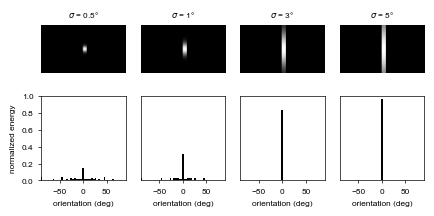

In [5]:
# Compare orientation energy across pRF sizes (degrees) using Gaussian windows centered on image
# Pulls monitor geometry from settings to convert deg → px.
import numpy as np
import matplotlib.pyplot as plt

# Monitor geometry and deg→px conversion
settings = io.load_settings()
screen_size_cm = settings["monitor"]["screen_size_cm"]
screen_size_pix = settings["monitor"]["screen_size_pix"]
distance_to_screen = settings["monitor"]["screen_distance_cm"]
screen_height_deg = calculate_visual_angle(screen_size_cm[1], distance_to_screen)
pixels_per_deg = screen_size_pix[1] / screen_height_deg

# Choose pRF sigmas in degrees (tweak as needed)
prf_sizes_deg = [0.5, 1.0, 3.0, 5.0]
prf_sizes_px = [sigma_deg * pixels_per_deg for sigma_deg in prf_sizes_deg]

# Grayscale bar image
if bar_image.ndim == 3:
    gray = bar_image.mean(axis=2)
else:
    gray = bar_image

# make it binary, make white and black into 1, and gray into 0.5
gray = np.where(gray != np.median(gray), 1, 0)

h, w = gray.shape
cy, cx = h // 2, w // 2 + 30

# Precompute orientation bin centers for plotting (matches orientation_spectrum bins)
nr_bins = 180
orient_edges = np.linspace(-90, 90, nr_bins)
orient_centers = (orient_edges[:-1] + orient_edges[1:]) / 2

energy_by_size = []
windowed_samples = []

y, x = np.ogrid[:h, :w]
for sigma_deg, sigma_px in zip(prf_sizes_deg, prf_sizes_px):
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray * mask
    windowed_samples.append(windowed)

    energy = orientation_spectrum(windowed, nr_bins)
    energy_by_size.append(energy / energy.sum())  # normalize for comparison

# Plot windowed images and orientation spectra
fig, axes = plt.subplots(
    2,
    len(prf_sizes_px),
    figsize=cm_to_inch(11.4, 6),
    gridspec_kw={"height_ratios": [1, 1]},


)
for idx, (sigma_deg, sigma_px) in enumerate(zip(prf_sizes_deg, prf_sizes_px)):
    axes[0, idx].imshow(windowed_samples[idx], cmap="gray")
    axes[0, idx].set_title(f"$\sigma$ = {sigma_deg:g}°", fontsize=6)
    axes[0, idx].axis("off")

    # axes[1, idx].plot(orient_centers, energy_by_size[idx], linewidth=0.5, color="k")
    # bar plot of energy by orientation bin
    axes[1, idx].bar(orient_centers, energy_by_size[idx], width=4, color="k", edgecolor="none")

    axes[1, idx].set_xlim(-90, 90)
    axes[1, idx].set_ylim(0, 1)
    axes[1, idx].set_xlabel("orientation (deg)")
    axes[1, idx].set_box_aspect(1)  # make second-row axes roughly square like the images
    if idx==0:
        axes[1, idx].set_ylabel("normalized energy")
    if idx>0:
        axes[1, idx].set_yticks([])

plt.tight_layout()
fig.savefig(figure_result_dir / f"broadband_orientation_energy.pdf", dpi=600, bbox_inches='tight')